In [26]:
import pandas as pd
import json
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm

# Wczytanie danych IFC
ifc_path = "../data/ifc_objects.csv"
ifc_df = pd.read_csv(ifc_path)
print(f"Wczytano {len(ifc_df)} obiektów IFC")

# Wczytanie danych bSDD z pliku CSV (plik z bSDD w formacie csv)
bsdd_path = "../data/contrastive_dataset/file02.csv"
bsdd_df = pd.read_csv(bsdd_path)

# Tworzymy kolumnę pełnego tekstu do embeddingu
bsdd_df["full_text"] = (
    bsdd_df["Code"].astype(str) + " — " +
    bsdd_df["Name"].fillna("") + " — " +
    bsdd_df["Text"].fillna("")
)

print(f"Wczytano {len(bsdd_df)} klas bSDD")

# Ładujemy model
model = SentenceTransformer("../models/fewshot_finetuned_contrastive_updated")

results = []

# Tworzymy embeddingi dla wszystkich klas bSDD raz na początku (oszczędność czasu)
bsdd_texts = bsdd_df["full_text"].tolist()
bsdd_embeddings = model.encode(bsdd_texts, convert_to_tensor=True)

for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))

    # Tworzymy embedding dla IFC (nazwa + opis)
    ifc_embedding = model.encode([ifc_name + " " + ifc_text], convert_to_tensor=True)

    # Obliczamy podobieństwa do całego bSDD
    similarities = util.cos_sim(ifc_embedding, bsdd_embeddings)[0]

    # Wybieramy najlepszy wynik
    best_idx = similarities.argmax().item()
    best_score = similarities[best_idx].item()
    best_class = bsdd_df.iloc[best_idx]

    print(f"IFC: {ifc_type} / {ifc_name} - Wybrano: {best_class['Code']} - {best_class['Name']} z podobieństwem {best_score:.4f}")

    results.append({
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300],
        "Kod_bSDD": best_class["Code"],
        "Nazwa_klasy_bSDD": best_class["Name"],
        "Podobieństwo": round(best_score, 4)
    })

# Zapis wyników
results_df = pd.DataFrame(results)
results_df.to_csv("../results/fewshot_finetuned_contrastive_updated.csv", index=False)
print("Zapisano wynik do fewshot_finetuned_contrastive_updated.csv")

# Opcjonalnie pokazanie wyników
display(results_df)

Wczytano 7 obiektów IFC
Wczytano 2023 klas bSDD


C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
 43%|████████████████████████████████████                                                | 3/7 [00:00<00:00, 15.13it/s]

IFC: IFCSLAB / floor - Wybrano: L-BF - Floor structure z podobieństwem 0.4951
IFC: IFCWALL / house - outer wall - house right front - Wybrano: L-NCB - Wall covering z podobieństwem 0.5339
IFC: IFCWALL / house - outer wall - house right back - Wybrano: L-BD - Wall structure z podobieństwem 0.5378
IFC: IFCWALL / house - outer wall - house left - Wybrano: L-BD - Wall structure z podobieństwem 0.5775


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 16.60it/s]

IFC: IFCWALL / plumbing wall - Wybrano: L-BD - Wall structure z podobieństwem 0.5063
IFC: IFCSLAB / house - roof - slab left - Wybrano: L-BE - Roof structure z podobieństwem 0.5869
IFC: IFCSLAB / house - roof - slab right - Wybrano: L-BE - Roof structure z podobieństwem 0.5632
Zapisano wynik do fewshot_finetuned_contrastive_updated.csv


,GlobalId,IfcType,Name,Opis_IFC,Kod_bSDD,Nazwa_klasy_bSDD,Podobieństwo
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.4951
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-NCB,Wall covering,0.5339
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5378
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.5775
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD,Wall structure,0.5063
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.5869
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.5632


In [5]:
sample_texts = [
    "Subfloor installation duct screed-covered",
    "Residual current circuit breaker (RCCB)",
    "Outer wall of a house"
]
embeddings = model.encode(sample_texts, convert_to_tensor=True)
cos_sim = util.cos_sim(embeddings, embeddings)
print(cos_sim)

tensor([[1.0000, 0.9888, 0.9704],
        [0.9888, 1.0000, 0.9748],
        [0.9704, 0.9748, 1.0000]])


C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [1]:
# TOP-3 ACCURACY
import pandas as pd
import json
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import torch

# Wczytanie danych IFC
ifc_path = "../data/ifc_objects.csv"
ifc_df = pd.read_csv(ifc_path)
print(f"Wczytano {len(ifc_df)} obiektów IFC")

# Wczytanie danych bSDD
bsdd_path = "../data/contrastive_dataset/file02.csv"
bsdd_df = pd.read_csv(bsdd_path)

# Tworzymy kolumnę pełnego tekstu do embeddingu
bsdd_df["full_text"] = (
    bsdd_df["Code"].astype(str) + " — " +
    bsdd_df["Name"].fillna("") + " — " +
    bsdd_df["Text"].fillna("")
)

print(f"Wczytano {len(bsdd_df)} klas bSDD")

# Ładujemy model
model = SentenceTransformer("../models/fewshot_finetuned_contrastive_updated")

results = []

# Embeddingi dla bSDD
bsdd_texts = bsdd_df["full_text"].tolist()
bsdd_embeddings = model.encode(bsdd_texts, convert_to_tensor=True)

for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))

    # Embedding IFC
    ifc_embedding = model.encode([ifc_name + " " + ifc_text], convert_to_tensor=True)

    # Podobieństwa
    similarities = util.cos_sim(ifc_embedding, bsdd_embeddings)[0]

    # TOP-3 wyniki
    top_results = torch.topk(similarities, k=3)
    top_indices = top_results.indices.tolist()
    top_scores = top_results.values.tolist()

    best_idx = top_indices[0]
    best_score = top_scores[0]

    # Tworzymy wpis do wyników
    results.append({
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300],
        "Top1_Kod_bSDD": bsdd_df.iloc[top_indices[0]]["Code"],
        "Top1_Nazwa_bSDD": bsdd_df.iloc[top_indices[0]]["Name"],
        "Top1_Podobieństwo": round(top_scores[0], 4),
        "Top2_Kod_bSDD": bsdd_df.iloc[top_indices[1]]["Code"],
        "Top2_Nazwa_bSDD": bsdd_df.iloc[top_indices[1]]["Name"],
        "Top2_Podobieństwo": round(top_scores[1], 4),
        "Top3_Kod_bSDD": bsdd_df.iloc[top_indices[2]]["Code"],
        "Top3_Nazwa_bSDD": bsdd_df.iloc[top_indices[2]]["Name"],
        "Top3_Podobieństwo": round(top_scores[2], 4),
    })

    print(f"IFC: {ifc_type} / {ifc_name}")
    for rank in range(3):
        print(f"   TOP-{rank+1}: {bsdd_df.iloc[top_indices[rank]]['Code']} - {bsdd_df.iloc[top_indices[rank]]['Name']} "
              f"({top_scores[rank]:.4f})")

# Zapis wyników
results_df = pd.DataFrame(results)
results_df.to_csv("../results/fewshot_finetuned_contrastive_updated_top3.csv", index=False)
print("Zapisano wynik do fewshot_finetuned_contrastive_updated_top3.csv")

# Opcjonalnie pokazanie wyników
display(results_df.head(10))

C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wczytano 7 obiektów IFC
Wczytano 2023 klas bSDD


C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 25.07it/s]

IFC: IFCSLAB / floor
   TOP-1: L-BF - Floor structure (0.4951)
   TOP-2: L-NCC - Flooring (0.4931)
   TOP-3: L-C_ - Ground surface construction system (0.4563)
IFC: IFCWALL / house - outer wall - house right front
   TOP-1: L-NCB - Wall covering (0.5339)
   TOP-2: L-BD - Wall structure (0.5240)
   TOP-3: EC000872 - Outer corner for wall duct (0.5150)
IFC: IFCWALL / house - outer wall - house right back
   TOP-1: L-BD - Wall structure (0.5378)
   TOP-2: L-NCB - Wall covering (0.5363)
   TOP-3: EC000872 - Outer corner for wall duct (0.5258)
IFC: IFCWALL / house - outer wall - house left
   TOP-1: L-BD - Wall structure (0.5775)
   TOP-2: L-NCB - Wall covering (0.5451)
   TOP-3: EC000872 - Outer corner for wall duct (0.4941)
IFC: IFCWALL / plumbing wall
   TOP-1: L-BD - Wall structure (0.5063)
   TOP-2: EC000023 - Cover for wall duct/Installation column (0.5018)
   TOP-3: EC001012 - Cover for corner for wall duct (0.4919)
IFC: IFCSLAB / house - roof - slab left
   TOP-1: L-BE - Roof struct

,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.4951,L-NCC,Flooring,0.4931,L-C_,Ground surface construction system,0.4563
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-NCB,Wall covering,0.5339,L-BD,Wall structure,0.5240,EC000872,Outer corner for wall duct,0.5150
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5378,L-NCB,Wall covering,0.5363,EC000872,Outer corner for wall duct,0.5258
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.5775,L-NCB,Wall covering,0.5451,EC000872,Outer corner for wall duct,0.4941
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD,Wall structure,0.5063,EC000023,Cover for wall duct/Installation column,0.5018,EC001012,Cover for corner for wall duct,0.4919
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.5869,L-NCE,Roofing,0.5087,L-AL,Roof tower,0.4660
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.5632,L-NCE,Roofing,0.5046,L-AL,Roof tower,0.4652


In [5]:
#POST PROCESSING
import pandas as pd
import re
import torch
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm

# Funkcje pomocnicze
def extract_keywords(text):
    if pd.isna(text):
        return []
    return re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())

def rerank_with_postprocessing(ifc_text, ifc_type, candidates, bsdd_df):
    ifc_keywords = extract_keywords(ifc_text) + [ifc_type.lower()]
    ifc_text_lower = ifc_text.lower()
    reranked = []

    general_terms = {"wall", "slab", "roof", "floor", "column"}
    technical_terms = {"duct", "corner", "cover", "pipe", "beam"}
    installation_terms = {"plumbing", "installation", "pipe", "duct", "column"}

    for idx, sim in candidates:
        bsdd_row = bsdd_df.iloc[idx]
        bsdd_text = str(bsdd_row["full_text"]).lower()

        score = sim

        # Boost za ogólne terminy
        for kw in ifc_keywords:
            if kw in general_terms and kw in bsdd_text:
                score += 0.02

        # Boost za dopasowanie techniczne
        for kw in ifc_keywords:
            if kw in technical_terms and kw in bsdd_text:
                score += 0.03

        # Kara za techniczne słowa TYLKO jeśli IFC nie sugeruje instalacji
        if not any(term in ifc_text_lower for term in installation_terms):
            for t in technical_terms:
                if t in bsdd_text and t not in ifc_text_lower:
                    score -= 0.03

        reranked.append((idx, score))

    return sorted(reranked, key=lambda x: x[1], reverse=True)

# Wczytanie danych IFC
ifc_path = "../data/ifc_objects.csv"
ifc_df = pd.read_csv(ifc_path)

# Wczytanie danych bSDD
bsdd_path = "../data/contrastive_dataset/file02.csv"
bsdd_df = pd.read_csv(bsdd_path)
bsdd_df["full_text"] = (
    bsdd_df["Code"].astype(str) + " — " +
    bsdd_df["Name"].fillna("") + " — " +
    bsdd_df["Text"].fillna("")
)

print(f"Wczytano {len(ifc_df)} obiektów IFC")
print(f"Wczytano {len(bsdd_df)} klas bSDD")

# Ładowanie modelu
model = SentenceTransformer("../models/fewshot_finetuned_contrastive_updated")

results = []

# Embeddingi bSDD
bsdd_texts = bsdd_df["full_text"].tolist()
bsdd_embeddings = model.encode(bsdd_texts, convert_to_tensor=True)

for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))
    full_ifc_text = ifc_name + " " + ifc_text

    # Embedding IFC
    ifc_embedding = model.encode([full_ifc_text], convert_to_tensor=True)

    # Podobieństwa
    similarities = util.cos_sim(ifc_embedding, bsdd_embeddings)[0]

    # TOP-3 surowe
    top_results = torch.topk(similarities, k=3)
    candidates = list(zip(top_results.indices.tolist(), top_results.values.tolist()))

    # Reranking post-processing
    reranked = rerank_with_postprocessing(full_ifc_text, ifc_type, candidates, bsdd_df)

    # Tworzymy wpis
    result_entry = {
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300]
    }

    # Zapisujemy wyniki (Top3 po post-processingu)
    for rank, (idx, score) in enumerate(reranked[:3]):
        result_entry[f"Top{rank+1}_Kod_bSDD"] = bsdd_df.iloc[idx]["Code"]
        result_entry[f"Top{rank+1}_Nazwa_bSDD"] = bsdd_df.iloc[idx]["Name"]
        result_entry[f"Top{rank+1}_Podobieństwo"] = round(score, 4)

    results.append(result_entry)

# Zapis do CSV
results_df = pd.DataFrame(results)
results_df.to_csv("../results/fewshot_finetuned_contrastive_postprocessed.csv", index=False)
print("Zapisano wynik do fewshot_finetuned_contrastive_postprocessed.csv")

# Wyniki
display(results_df.head(10))

Wczytano 7 obiektów IFC
Wczytano 2023 klas bSDD


C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 68.16it/s]

Zapisano wynik do fewshot_finetuned_contrastive_postprocessed.csv


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.5351,L-NCC,Flooring,0.5331,L-C_,Ground surface construction system,0.4563
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-BD,Wall structure,0.5640,L-NCB,Wall covering,0.5439,EC000872,Outer corner for wall duct,0.4950
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5778,L-NCB,Wall covering,0.5463,EC000872,Outer corner for wall duct,0.5058
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.6175,L-NCB,Wall covering,0.5551,EC000872,Outer corner for wall duct,0.4741
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD,Wall structure,0.5463,EC000023,Cover for wall duct/Installation column,0.5418,EC001012,Cover for corner for wall duct,0.5319
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6269,L-NCE,Roofing,0.5487,L-AL,Roof tower,0.5060
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6032,L-NCE,Roofing,0.5446,L-AL,Roof tower,0.5052


In [6]:
# Klasteryzacja - SUPPORT
from sklearn.cluster import KMeans

num_clusters = 20
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(bsdd_embeddings.cpu().numpy())
bsdd_df["Cluster"] = cluster_labels
print("Dodano etykiety klastrów do klas bSDD")

for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))
    full_ifc_text = ifc_name + " " + ifc_text

    # Embedding IFC
    ifc_embedding = model.encode([full_ifc_text], convert_to_tensor=True)

    # Predykcja klastra dla IFC
    ifc_cluster = kmeans.predict(ifc_embedding.cpu().numpy())[0]

    # Wybieramy tylko embeddingi z tego klastra
    cluster_mask = (bsdd_df["Cluster"] == ifc_cluster)
    cluster_embeddings = bsdd_embeddings[cluster_mask.values]
    cluster_df = bsdd_df[cluster_mask]

    # Podobieństwa tylko w obrębie klastra
    similarities = util.cos_sim(ifc_embedding, cluster_embeddings)[0]

    # TOP-3 w obrębie klastra
    top_results = torch.topk(similarities, k=3)
    candidates = list(zip(top_results.indices.tolist(), top_results.values.tolist()))

    # Mapowanie indeksów lokalnych (klastra) → na indeksy globalne (bsdd_df)
    candidates_global = [(cluster_df.index[idx], sim) for idx, sim in candidates]

    # Reranking post-processing
    reranked = rerank_with_postprocessing(full_ifc_text, ifc_type, candidates_global, bsdd_df)

    # Tworzymy wpis
    result_entry = {
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300]
    }

    # Zapisujemy wyniki (Top3 po post-processingu)
    for rank, (idx, score) in enumerate(reranked[:3]):
        result_entry[f"Top{rank+1}_Kod_bSDD"] = bsdd_df.loc[idx]["Code"]
        result_entry[f"Top{rank+1}_Nazwa_bSDD"] = bsdd_df.loc[idx]["Name"]
        result_entry[f"Top{rank+1}_Podobieństwo"] = round(score, 4)

    results.append(result_entry)

results_df = pd.DataFrame(results)
results_df.to_csv("../results/fewshot_finetuned_contrastive_postprocessed_clustered.csv", index=False)
print("Zapisano wynik do fewshot_finetuned_contrastive_postprocessed_clustered.csv")

display(results_df.head(10))

Dodano etykiety klastrów do klas bSDD


  0%|                                                                                            | 0/7 [00:00<?, ?it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
 14%|████████████                                                                        | 1/7 [00:00<00:01,  5.39it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, *

Zapisano wynik do fewshot_finetuned_contrastive_postprocessed_clustered.csv


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.5351,L-NCC,Flooring,0.5331,L-C_,Ground surface construction system,0.4563
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-BD,Wall structure,0.5640,L-NCB,Wall covering,0.5439,EC000872,Outer corner for wall duct,0.4950
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5778,L-NCB,Wall covering,0.5463,EC000872,Outer corner for wall duct,0.5058
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.6175,L-NCB,Wall covering,0.5551,EC000872,Outer corner for wall duct,0.4741
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD,Wall structure,0.5463,EC000023,Cover for wall duct/Installation column,0.5418,EC001012,Cover for corner for wall duct,0.5319
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6269,L-NCE,Roofing,0.5487,L-AL,Roof tower,0.5060
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6032,L-NCE,Roofing,0.5446,L-AL,Roof tower,0.5052
7,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.5351,L-NCC,Flooring,0.5331,L-C_,Ground surface construction system,0.4563
8,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-BD,Wall structure,0.5640,L-NCB,Wall covering,0.5439,L-AD,Wall construction,0.4900
9,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5778,L-NCB,Wall covering,0.5463,L-AD,Wall construction,0.4872


In [7]:
# TOP-3 + POSTPROCESSING + KLASTRY + WARSTWA KLASYFIKACYJNA
import pandas as pd
import torch
import re
import joblib
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
from sklearn.cluster import KMeans

# Funkcje pomocnicze
def extract_keywords(text):
    if pd.isna(text):
        return []
    return re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())

def rerank_with_postprocessing(ifc_text, ifc_type, candidates, bsdd_df):
    ifc_keywords = extract_keywords(ifc_text) + [ifc_type.lower()]
    ifc_text_lower = ifc_text.lower()
    reranked = []

    general_terms = {"wall", "slab", "roof", "floor", "column"}
    technical_terms = {"duct", "corner", "cover", "pipe", "beam"}
    installation_terms = {"plumbing", "installation", "pipe", "duct", "column"}

    for idx, sim in candidates:
        bsdd_row = bsdd_df.iloc[idx]
        bsdd_text = str(bsdd_row["full_text"]).lower()
        score = sim

        # Boost za ogólne terminy
        for kw in ifc_keywords:
            if kw in general_terms and kw in bsdd_text:
                score += 0.02

        # Boost za dopasowanie techniczne
        for kw in ifc_keywords:
            if kw in technical_terms and kw in bsdd_text:
                score += 0.03

        # Kara za techniczne słowa TYLKO jeśli IFC nie sugeruje instalacji
        if not any(term in ifc_text_lower for term in installation_terms):
            for t in technical_terms:
                if t in bsdd_text and t not in ifc_text_lower:
                    score -= 0.03

        reranked.append((idx, score))

    return sorted(reranked, key=lambda x: x[1], reverse=True)

def add_classifier_predictions(ifc_embedding, result_entry, clf):
    ifc_embedding_np = ifc_embedding.cpu().numpy()
    probas = clf.predict_proba(ifc_embedding_np)[0]

    top3_idx = probas.argsort()[-3:][::-1]
    top3_codes = [clf.classes_[i] for i in top3_idx]
    top3_scores = [probas[i] for i in top3_idx]

    result_entry["Classifier_Top1_Code"] = top3_codes[0]
    result_entry["Classifier_Top1_Score"] = round(top3_scores[0], 4)
    result_entry["Classifier_Top2_Code"] = top3_codes[1]
    result_entry["Classifier_Top2_Score"] = round(top3_scores[1], 4)
    result_entry["Classifier_Top3_Code"] = top3_codes[2]
    result_entry["Classifier_Top3_Score"] = round(top3_scores[2], 4)

    # zgodność klasyfikatora z Top-1 cos_sim
    if "Top1_Kod_bSDD" in result_entry:
        result_entry["Hybryda_Zgodnosc"] = (top3_codes[0] == result_entry["Top1_Kod_bSDD"])

    return result_entry


# Dane wejściowe
ifc_path = "../data/ifc_objects.csv"
bsdd_path = "../data/contrastive_dataset/file02.csv"

ifc_df = pd.read_csv(ifc_path)
bsdd_df = pd.read_csv(bsdd_path)
bsdd_df["full_text"] = (
    bsdd_df["Code"].astype(str) + " — " +
    bsdd_df["Name"].fillna("") + " — " +
    bsdd_df["Text"].fillna("")
)

print(f"Wczytano {len(ifc_df)} obiektów IFC")
print(f"Wczytano {len(bsdd_df)} klas bSDD")

# Model embeddingów
model = SentenceTransformer("../models/fewshot_finetuned_contrastive_updated")

# Klasyfikator
clf = joblib.load("../models/fewshot_with_classifier/classifier.pkl")

# Embeddingi bSDD
bsdd_texts = bsdd_df["full_text"].tolist()
bsdd_embeddings = model.encode(bsdd_texts, convert_to_tensor=True)

# TOP-3 accuracy
results_top3 = []
for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))
    full_ifc_text = ifc_name + " " + ifc_text

    ifc_embedding = model.encode([full_ifc_text], convert_to_tensor=True)
    similarities = util.cos_sim(ifc_embedding, bsdd_embeddings)[0]
    top_results = torch.topk(similarities, k=3)
    top_indices = top_results.indices.tolist()
    top_scores = top_results.values.tolist()

    entry = {
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300],
        "Top1_Kod_bSDD": bsdd_df.iloc[top_indices[0]]["Code"],
        "Top1_Nazwa_bSDD": bsdd_df.iloc[top_indices[0]]["Name"],
        "Top1_Podobieństwo": round(top_scores[0], 4),
        "Top2_Kod_bSDD": bsdd_df.iloc[top_indices[1]]["Code"],
        "Top2_Nazwa_bSDD": bsdd_df.iloc[top_indices[1]]["Name"],
        "Top2_Podobieństwo": round(top_scores[1], 4),
        "Top3_Kod_bSDD": bsdd_df.iloc[top_indices[2]]["Code"],
        "Top3_Nazwa_bSDD": bsdd_df.iloc[top_indices[2]]["Name"],
        "Top3_Podobieństwo": round(top_scores[2], 4),
    }

    entry = add_classifier_predictions(ifc_embedding, entry, clf)
    results_top3.append(entry)

df_top3 = pd.DataFrame(results_top3)
df_top3.to_csv("../results/hybryda_top3.csv", index=False)
print("Zapisano ../results/hybryda_top3.csv")

# Post-processing
results_post = []
for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))
    full_ifc_text = ifc_name + " " + ifc_text

    ifc_embedding = model.encode([full_ifc_text], convert_to_tensor=True)
    similarities = util.cos_sim(ifc_embedding, bsdd_embeddings)[0]
    top_results = torch.topk(similarities, k=3)
    candidates = list(zip(top_results.indices.tolist(), top_results.values.tolist()))
    reranked = rerank_with_postprocessing(full_ifc_text, ifc_type, candidates, bsdd_df)

    entry = {
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300]
    }
    for rank, (idx, score) in enumerate(reranked[:3]):
        entry[f"Top{rank+1}_Kod_bSDD"] = bsdd_df.iloc[idx]["Code"]
        entry[f"Top{rank+1}_Nazwa_bSDD"] = bsdd_df.iloc[idx]["Name"]
        entry[f"Top{rank+1}_Podobieństwo"] = round(score, 4)

    entry = add_classifier_predictions(ifc_embedding, entry, clf)
    results_post.append(entry)

df_post = pd.DataFrame(results_post)
df_post.to_csv("../results/hybryda_postprocessed.csv", index=False)
print("Zapisano ../results/hybryda_postprocessed.csv")


# Klasteryzacja + post-processing
kmeans = KMeans(n_clusters=20, random_state=42)
cluster_labels = kmeans.fit_predict(bsdd_embeddings.cpu().numpy())
bsdd_df["Cluster"] = cluster_labels

results_cluster = []
for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))
    full_ifc_text = ifc_name + " " + ifc_text

    ifc_embedding = model.encode([full_ifc_text], convert_to_tensor=True)
    ifc_cluster = kmeans.predict(ifc_embedding.cpu().numpy())[0]

    cluster_mask = (bsdd_df["Cluster"] == ifc_cluster)
    cluster_embeddings = bsdd_embeddings[cluster_mask.values]
    cluster_df = bsdd_df[cluster_mask]

    similarities = util.cos_sim(ifc_embedding, cluster_embeddings)[0]
    top_results = torch.topk(similarities, k=3)
    candidates = [(cluster_df.index[idx], sim) for idx, sim in zip(top_results.indices.tolist(), top_results.values.tolist())]

    reranked = rerank_with_postprocessing(full_ifc_text, ifc_type, candidates, bsdd_df)

    entry = {
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300]
    }
    for rank, (idx, score) in enumerate(reranked[:3]):
        entry[f"Top{rank+1}_Kod_bSDD"] = bsdd_df.loc[idx]["Code"]
        entry[f"Top{rank+1}_Nazwa_bSDD"] = bsdd_df.loc[idx]["Name"]
        entry[f"Top{rank+1}_Podobieństwo"] = round(score, 4)

    entry = add_classifier_predictions(ifc_embedding, entry, clf)
    results_cluster.append(entry)

df_cluster = pd.DataFrame(results_cluster)
df_cluster.to_csv("../results/hybryda_clustered.csv", index=False)
print("Zapisano ../results/hybryda_clustered.csv")

# Podgląd wyników
display(df_top3)
display(df_post)
display(df_cluster)

Wczytano 7 obiektów IFC
Wczytano 2023 klas bSDD


C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
  0%|                                                                                            | 0/7 [00:00<?, ?it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encod

Zapisano ../results/hybryda_top3.csv


  0%|                                                                                            | 0/7 [00:00<?, ?it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encod

Zapisano ../results/hybryda_postprocessed.csv


  0%|                                                                                            | 0/7 [00:00<?, ?it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encod

Zapisano ../results/hybryda_clustered.csv


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo,Classifier_Top1_Code,Classifier_Top1_Score,Classifier_Top2_Code,Classifier_Top2_Score,Classifier_Top3_Code,Classifier_Top3_Score,Hybryda_Zgodnosc
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.4951,L-NCC,Flooring,0.4931,L-C_,Ground surface construction system,0.4563,EF_30_20,0.4958,[L]B,0.0973,[L]AD,0.0973,False
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-NCB,Wall covering,0.5339,L-BD,Wall structure,0.5240,EC000872,Outer corner for wall duct,0.5150,[L]AD,0.1645,[L]B,0.1645,EF_30_20,0.1461,False
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5378,L-NCB,Wall covering,0.5363,EC000872,Outer corner for wall duct,0.5258,EF_30_20,0.1695,[L]AD,0.1426,[L]B,0.1426,False
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.5775,L-NCB,Wall covering,0.5451,EC000872,Outer corner for wall duct,0.4941,EF_30_20,0.1622,EF_30,0.1456,[L]AD,0.1421,False
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD,Wall structure,0.5063,EC000023,Cover for wall duct/Installation column,0.5018,EC001012,Cover for corner for wall duct,0.4919,EF_25_10,0.2401,EF_30_20,0.1961,EF_30,0.1820,False
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.5869,L-NCE,Roofing,0.5087,L-AL,Roof tower,0.4660,EF_35_10_40,0.1663,[L]AD,0.1373,[L]B,0.1373,False
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.5632,L-NCE,Roofing,0.5046,L-AL,Roof tower,0.4652,EF_30_20,0.1551,EF_35_10_40,0.1506,[L]AD,0.1312,False


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo,Classifier_Top1_Code,Classifier_Top1_Score,Classifier_Top2_Code,Classifier_Top2_Score,Classifier_Top3_Code,Classifier_Top3_Score,Hybryda_Zgodnosc
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.5351,L-NCC,Flooring,0.5331,L-C_,Ground surface construction system,0.4563,EF_30_20,0.4958,[L]B,0.0973,[L]AD,0.0973,False
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-BD,Wall structure,0.5640,L-NCB,Wall covering,0.5439,EC000872,Outer corner for wall duct,0.4950,[L]AD,0.1645,[L]B,0.1645,EF_30_20,0.1461,False
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5778,L-NCB,Wall covering,0.5463,EC000872,Outer corner for wall duct,0.5058,EF_30_20,0.1695,[L]AD,0.1426,[L]B,0.1426,False
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.6175,L-NCB,Wall covering,0.5551,EC000872,Outer corner for wall duct,0.4741,EF_30_20,0.1622,EF_30,0.1456,[L]AD,0.1421,False
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD,Wall structure,0.5463,EC000023,Cover for wall duct/Installation column,0.5418,EC001012,Cover for corner for wall duct,0.5319,EF_25_10,0.2401,EF_30_20,0.1961,EF_30,0.1820,False
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6269,L-NCE,Roofing,0.5487,L-AL,Roof tower,0.5060,EF_35_10_40,0.1663,[L]AD,0.1373,[L]B,0.1373,False
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6032,L-NCE,Roofing,0.5446,L-AL,Roof tower,0.5052,EF_30_20,0.1551,EF_35_10_40,0.1506,[L]AD,0.1312,False


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo,Classifier_Top1_Code,Classifier_Top1_Score,Classifier_Top2_Code,Classifier_Top2_Score,Classifier_Top3_Code,Classifier_Top3_Score,Hybryda_Zgodnosc
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.5351,L-NCC,Flooring,0.5331,L-C_,Ground surface construction system,0.4563,EF_30_20,0.4958,[L]B,0.0973,[L]AD,0.0973,False
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-BD,Wall structure,0.5640,L-NCB,Wall covering,0.5439,L-AD,Wall construction,0.4900,[L]AD,0.1645,[L]B,0.1645,EF_30_20,0.1461,False
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5778,L-NCB,Wall covering,0.5463,L-AD,Wall construction,0.4872,EF_30_20,0.1695,[L]AD,0.1426,[L]B,0.1426,False
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.6175,L-NCB,Wall covering,0.5551,L-AD,Wall construction,0.5162,EF_30_20,0.1622,EF_30,0.1456,[L]AD,0.1421,False
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD,Wall structure,0.5463,L-B_,Structural system,0.4465,L-BB,Foundation structure,0.4330,EF_25_10,0.2401,EF_30_20,0.1961,EF_30,0.1820,False
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6269,L-NCE,Roofing,0.5487,L-AL,Roof tower,0.5060,EF_35_10_40,0.1663,[L]AD,0.1373,[L]B,0.1373,False
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6032,L-NCE,Roofing,0.5446,L-AL,Roof tower,0.5052,EF_30_20,0.1551,EF_35_10_40,0.1506,[L]AD,0.1312,False


In [1]:
# TOP-3 + POSTPROCESSING + KLASTRY + WARSTWA KLASYFIKACYJNA + AUGMENTACJA
import pandas as pd
import torch
import re
import joblib
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
from sklearn.cluster import KMeans

# Funkcje pomocnicze
def extract_keywords(text):
    if pd.isna(text):
        return []
    return re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())

def augment_text(ifc_text, ifc_type):
    """
    Tworzy proste warianty opisu IFC dla poprawy embeddingów.
    """
    variants = []

    # 1. Oryginał
    variants.append(ifc_text.strip())

    # 2. Dodanie IfcType
    if ifc_type:
        variants.append(f"{ifc_type} element: {ifc_text}")
        variants.append(f"{ifc_text} (IfcType: {ifc_type})")

    # 3. Synonimy najczęstszych typów
    synonyms = {
        "wall": ["partition", "barrier", "external wall", "internal wall"],
        "slab": ["floor plate", "concrete slab", "prefabricated slab"],
        "roof": ["roofing", "roof structure", "covering"],
        "column": ["pillar", "support column"],
        "beam": ["support beam", "girder"],
        "duct": ["air channel", "ventilation duct"],
        "pipe": ["installation pipe", "tube", "pipeline"]
    }
    for word, syns in synonyms.items():
        if word in ifc_text.lower():
            for s in syns:
                variants.append(ifc_text.replace(word, s))

    # usunięcie duplikatów
    variants = list({v.strip() for v in variants if v.strip()})
    return variants


def embed_with_augmentation(model, ifc_text, ifc_type):
    """
    Generuje embedding na podstawie kilku wariantów (średnia).
    """
    aug_texts = augment_text(ifc_text, ifc_type)
    embeddings = model.encode(aug_texts, convert_to_tensor=True)
    return embeddings.mean(dim=0, keepdim=True)


def rerank_with_postprocessing(ifc_text, ifc_type, candidates, bsdd_df):
    ifc_keywords = extract_keywords(ifc_text) + [ifc_type.lower()]
    ifc_text_lower = ifc_text.lower()
    reranked = []

    general_terms = {"wall", "slab", "roof", "floor", "column"}
    technical_terms = {"duct", "corner", "cover", "pipe", "beam"}
    installation_terms = {"plumbing", "installation", "pipe", "duct", "column"}

    for idx, sim in candidates:
        bsdd_row = bsdd_df.iloc[idx]
        bsdd_text = str(bsdd_row["full_text"]).lower()
        score = sim

        # Boost za ogólne terminy
        for kw in ifc_keywords:
            if kw in general_terms and kw in bsdd_text:
                score += 0.02

        # Boost za dopasowanie techniczne
        for kw in ifc_keywords:
            if kw in technical_terms and kw in bsdd_text:
                score += 0.03

        # Kara za techniczne słowa TYLKO jeśli IFC nie sugeruje instalacji
        if not any(term in ifc_text_lower for term in installation_terms):
            for t in technical_terms:
                if t in bsdd_text and t not in ifc_text_lower:
                    score -= 0.03

        reranked.append((idx, score))

    return sorted(reranked, key=lambda x: x[1], reverse=True)

def add_classifier_predictions(ifc_embedding, result_entry, clf):
    ifc_embedding_np = ifc_embedding.cpu().numpy()
    probas = clf.predict_proba(ifc_embedding_np)[0]

    top3_idx = probas.argsort()[-3:][::-1]
    top3_codes = [clf.classes_[i] for i in top3_idx]
    top3_scores = [probas[i] for i in top3_idx]

    result_entry["Classifier_Top1_Code"] = top3_codes[0]
    result_entry["Classifier_Top1_Score"] = round(top3_scores[0], 4)
    result_entry["Classifier_Top2_Code"] = top3_codes[1]
    result_entry["Classifier_Top2_Score"] = round(top3_scores[1], 4)
    result_entry["Classifier_Top3_Code"] = top3_codes[2]
    result_entry["Classifier_Top3_Score"] = round(top3_scores[2], 4)

    # zgodność klasyfikatora z Top-1 cos_sim
    if "Top1_Kod_bSDD" in result_entry:
        result_entry["Hybryda_Zgodnosc"] = (top3_codes[0] == result_entry["Top1_Kod_bSDD"])

    return result_entry


# Dane wejściowe
ifc_path = "../data/ifc_objects.csv"
bsdd_path = "../data/contrastive_dataset/file02.csv"

ifc_df = pd.read_csv(ifc_path)
bsdd_df = pd.read_csv(bsdd_path)
bsdd_df["full_text"] = (
    bsdd_df["Code"].astype(str) + " — " +
    bsdd_df["Name"].fillna("") + " — " +
    bsdd_df["Text"].fillna("")
)

print(f"Wczytano {len(ifc_df)} obiektów IFC")
print(f"Wczytano {len(bsdd_df)} klas bSDD")

# Model embeddingów
model = SentenceTransformer("../models/fewshot_finetuned_contrastive_updated")

# Klasyfikator
clf = joblib.load("../models/fewshot_with_classifier/classifier.pkl")

# Embeddingi bSDD
bsdd_texts = bsdd_df["full_text"].tolist()
bsdd_embeddings = model.encode(bsdd_texts, convert_to_tensor=True)

# TOP-3 accuracy
results_top3 = []
for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))
    full_ifc_text = ifc_name + " " + ifc_text

    ifc_embedding = embed_with_augmentation(model, full_ifc_text, ifc_type)
    similarities = util.cos_sim(ifc_embedding, bsdd_embeddings)[0]
    top_results = torch.topk(similarities, k=3)
    top_indices = top_results.indices.tolist()
    top_scores = top_results.values.tolist()

    entry = {
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300],
        "Top1_Kod_bSDD": bsdd_df.iloc[top_indices[0]]["Code"],
        "Top1_Nazwa_bSDD": bsdd_df.iloc[top_indices[0]]["Name"],
        "Top1_Podobieństwo": round(top_scores[0], 4),
        "Top2_Kod_bSDD": bsdd_df.iloc[top_indices[1]]["Code"],
        "Top2_Nazwa_bSDD": bsdd_df.iloc[top_indices[1]]["Name"],
        "Top2_Podobieństwo": round(top_scores[1], 4),
        "Top3_Kod_bSDD": bsdd_df.iloc[top_indices[2]]["Code"],
        "Top3_Nazwa_bSDD": bsdd_df.iloc[top_indices[2]]["Name"],
        "Top3_Podobieństwo": round(top_scores[2], 4),
    }

    entry = add_classifier_predictions(ifc_embedding, entry, clf)
    results_top3.append(entry)

df_top3 = pd.DataFrame(results_top3)
df_top3.to_csv("../results/hybryda_top3_2.csv", index=False)
print("Zapisano ../results/hybryda_top3_2.csv")

# Post-processing
results_post = []
for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))
    full_ifc_text = ifc_name + " " + ifc_text

    ifc_embedding = embed_with_augmentation(model, full_ifc_text, ifc_type)
    similarities = util.cos_sim(ifc_embedding, bsdd_embeddings)[0]
    top_results = torch.topk(similarities, k=3)
    candidates = list(zip(top_results.indices.tolist(), top_results.values.tolist()))
    reranked = rerank_with_postprocessing(full_ifc_text, ifc_type, candidates, bsdd_df)

    entry = {
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300]
    }
    for rank, (idx, score) in enumerate(reranked[:3]):
        entry[f"Top{rank+1}_Kod_bSDD"] = bsdd_df.iloc[idx]["Code"]
        entry[f"Top{rank+1}_Nazwa_bSDD"] = bsdd_df.iloc[idx]["Name"]
        entry[f"Top{rank+1}_Podobieństwo"] = round(score, 4)

    entry = add_classifier_predictions(ifc_embedding, entry, clf)
    results_post.append(entry)

df_post = pd.DataFrame(results_post)
df_post.to_csv("../results/hybryda_postprocessed2.csv", index=False)
print("Zapisano ../results/hybryda_postprocessed2.csv")


# Klasteryzacja + post-processing
kmeans = KMeans(n_clusters=20, random_state=42)
cluster_labels = kmeans.fit_predict(bsdd_embeddings.cpu().numpy())
bsdd_df["Cluster"] = cluster_labels

results_cluster = []
for i, row in tqdm(ifc_df.iterrows(), total=len(ifc_df)):
    ifc_type = row.get("IfcType", "").upper()
    ifc_name = str(row.get("Name", ""))
    ifc_text = str(row.get("Text", ""))
    full_ifc_text = ifc_name + " " + ifc_text

    ifc_embedding = embed_with_augmentation(model, full_ifc_text, ifc_type)
    ifc_cluster = kmeans.predict(ifc_embedding.cpu().numpy())[0]

    cluster_mask = (bsdd_df["Cluster"] == ifc_cluster)
    cluster_embeddings = bsdd_embeddings[cluster_mask.values]
    cluster_df = bsdd_df[cluster_mask]

    similarities = util.cos_sim(ifc_embedding, cluster_embeddings)[0]
    top_results = torch.topk(similarities, k=3)
    candidates = [(cluster_df.index[idx], sim) for idx, sim in zip(top_results.indices.tolist(), top_results.values.tolist())]

    reranked = rerank_with_postprocessing(full_ifc_text, ifc_type, candidates, bsdd_df)

    entry = {
        "GlobalId": row.get("GlobalId", ""),
        "IfcType": ifc_type,
        "Name": ifc_name,
        "Opis_IFC": ifc_text[:300]
    }
    for rank, (idx, score) in enumerate(reranked[:3]):
        entry[f"Top{rank+1}_Kod_bSDD"] = bsdd_df.loc[idx]["Code"]
        entry[f"Top{rank+1}_Nazwa_bSDD"] = bsdd_df.loc[idx]["Name"]
        entry[f"Top{rank+1}_Podobieństwo"] = round(score, 4)

    entry = add_classifier_predictions(ifc_embedding, entry, clf)
    results_cluster.append(entry)

df_cluster = pd.DataFrame(results_cluster)
df_cluster.to_csv("../results/hybryda_clustered2.csv", index=False)
print("Zapisano ../results/hybryda_clustered2.csv")

# Podgląd wyników
display(df_top3)
display(df_post)
display(df_cluster)

C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wczytano 7 obiektów IFC
Wczytano 2023 klas bSDD


C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
 14%|████████████                                                                        | 1/7 [00:00<00:01,  4.87it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encod

Zapisano ../results/hybryda_top3_2.csv


  0%|                                                                                            | 0/7 [00:00<?, ?it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encod

...

  0%|                                                                                            | 0/7 [00:00<?, ?it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
 29%|████████████████████████                                                            | 2/7 [00:00<00:00, 19.42it/s]C:\Users\chlip\anaconda3\envs\bim-nlp\lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, *

Zapisano ../results/hybryda_clustered2.csv


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo,Classifier_Top1_Code,Classifier_Top1_Score,Classifier_Top2_Code,Classifier_Top2_Score,Classifier_Top3_Code,Classifier_Top3_Score,Hybryda_Zgodnosc
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.5368,L-NCC,Flooring,0.5296,L-C_,Ground surface construction system,0.4683,EF_30_20,0.4045,[L]AD,0.1062,[L]B,0.1062,False
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-NCB,Wall covering,0.5088,L-BD,Wall structure,0.5056,EC000872,Outer corner for wall duct,0.5027,[L]AD,0.1689,[L]B,0.1689,EF_30_20,0.1272,False
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5193,EC000872,Outer corner for wall duct,0.5117,L-NCB,Wall covering,0.5112,[L]AD,0.1483,[L]B,0.1483,EF_30_20,0.1429,False
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.5527,L-NCB,Wall covering,0.5195,EC000872,Outer corner for wall duct,0.4818,[L]AD,0.1498,[L]B,0.1498,EF_30,0.1379,False
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,EC000023,Cover for wall duct/Installation column,0.5298,L-BD,Wall structure,0.5102,EC000220,Wall transit for cables and tubes,0.5042,EF_25_10,0.2372,EF_30,0.1749,EF_30_20,0.1690,False
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.5948,L-NCE,Roofing,0.4980,L-BG,Ceiling structure,0.4801,EF_35_10_40,0.1529,EF_30_20,0.1452,[L]AD,0.1351,False
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.5701,L-NCE,Roofing,0.4991,E-AAB,House for multiple occupation,0.4568,EF_30_20,0.1697,EF_35_10_40,0.1384,[L]AD,0.1324,False


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo,Classifier_Top1_Code,Classifier_Top1_Score,Classifier_Top2_Code,Classifier_Top2_Score,Classifier_Top3_Code,Classifier_Top3_Score,Hybryda_Zgodnosc
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.5768,L-NCC,Flooring,0.5696,L-C_,Ground surface construction system,0.4683,EF_30_20,0.4045,[L]AD,0.1062,[L]B,0.1062,False
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-BD,Wall structure,0.5456,L-NCB,Wall covering,0.5188,EC000872,Outer corner for wall duct,0.4827,[L]AD,0.1689,[L]B,0.1689,EF_30_20,0.1272,False
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5593,L-NCB,Wall covering,0.5212,EC000872,Outer corner for wall duct,0.4917,[L]AD,0.1483,[L]B,0.1483,EF_30_20,0.1429,False
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.5927,L-NCB,Wall covering,0.5295,EC000872,Outer corner for wall duct,0.4618,[L]AD,0.1498,[L]B,0.1498,EF_30,0.1379,False
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,EC000023,Cover for wall duct/Installation column,0.5698,L-BD,Wall structure,0.5502,EC000220,Wall transit for cables and tubes,0.5442,EF_25_10,0.2372,EF_30,0.1749,EF_30_20,0.1690,False
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6348,L-NCE,Roofing,0.5380,L-BG,Ceiling structure,0.4801,EF_35_10_40,0.1529,EF_30_20,0.1452,[L]AD,0.1351,False
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6101,L-NCE,Roofing,0.5391,E-AAB,House for multiple occupation,0.4568,EF_30_20,0.1697,EF_35_10_40,0.1384,[L]AD,0.1324,False


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD,Top1_Nazwa_bSDD,Top1_Podobieństwo,Top2_Kod_bSDD,Top2_Nazwa_bSDD,Top2_Podobieństwo,Top3_Kod_bSDD,Top3_Nazwa_bSDD,Top3_Podobieństwo,Classifier_Top1_Code,Classifier_Top1_Score,Classifier_Top2_Code,Classifier_Top2_Score,Classifier_Top3_Code,Classifier_Top3_Score,Hybryda_Zgodnosc
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF,Floor structure,0.5768,L-NCC,Flooring,0.5696,L-C_,Ground surface construction system,0.4683,EF_30_20,0.4045,[L]AD,0.1062,[L]B,0.1062,False
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-BD,Wall structure,0.5456,L-NCB,Wall covering,0.5188,L-AD,Wall construction,0.4855,[L]AD,0.1689,[L]B,0.1689,EF_30_20,0.1272,False
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD,Wall structure,0.5593,L-NCB,Wall covering,0.5212,L-AD,Wall construction,0.4843,[L]AD,0.1483,[L]B,0.1483,EF_30_20,0.1429,False
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD,Wall structure,0.5927,L-NCB,Wall covering,0.5295,L-AD,Wall construction,0.5079,[L]AD,0.1498,[L]B,0.1498,EF_30,0.1379,False
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD,Wall structure,0.5502,L-B_,Structural system,0.4666,L-BB,Foundation structure,0.4474,EF_25_10,0.2372,EF_30,0.1749,EF_30_20,0.1690,False
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6348,L-NCE,Roofing,0.5380,L-BG,Ceiling structure,0.4801,EF_35_10_40,0.1529,EF_30_20,0.1452,[L]AD,0.1351,False
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE,Roof structure,0.6101,L-NCE,Roofing,0.5391,L-AL,Roof tower,0.4909,EF_30_20,0.1697,EF_35_10_40,0.1384,[L]AD,0.1324,False


In [4]:
# Eksport pojedynczej etykiety dla każdego IFC (z progiem - threshold)
import json

THRESHOLD = 0.5  # czułość (można dostosować)

# df_post - z post-processing
# df_cluster - z wykorzystaniem klasteryzacji
df = df_post.copy()  # <- df_post lub df_cluster

final_rows = []
for _, r in df.iterrows():
    global_id = r.get("GlobalId", "")
    ifc_type = r.get("IfcType", "")
    name = r.get("Name", "")
    opis = r.get("Opis_IFC", "")

    top1_code = r.get("Top1_Kod_bSDD")
    top1_score = float(r.get("Top1_Podobieństwo", 0) or 0)

    clf_code = r.get("Classifier_Top1_Code")
    clf_score = float(r.get("Classifier_Top1_Score", 0) or 0)

    # reguła wyboru
    source = None
    chosen_code = None
    chosen_score = None

    if top1_score >= THRESHOLD:
        chosen_code = top1_code
        chosen_score = top1_score
        source = "cos_sim_postprocessed"
    elif clf_score >= THRESHOLD:
        chosen_code = clf_code
        chosen_score = clf_score
        source = "classifier"
    else:
        chosen_code = "UNKNOWN"
        chosen_score = max(top1_score, clf_score)
        source = "low_confidence"

    row_out = {
        "GlobalId": global_id,
        "IfcType": ifc_type,
        "Name": name,
        "Opis_IFC": opis,
        "Chosen_Code": chosen_code,
        "Chosen_Score": round(chosen_score, 4),
        "Source": source,
        "Top1_CosSim_Code": top1_code,
        "Top1_CosSim_Score": round(top1_score, 4),
        "Classifier_Top1_Code": clf_code,
        "Classifier_Top1_Score": round(clf_score, 4)
    }
    final_rows.append(row_out)

final_df = pd.DataFrame(final_rows)
final_df.to_csv("../results/hybryda_final_labels.csv", index=False)
with open("../results/hybryda_final_labels.json", "w", encoding="utf-8") as f:
    json.dump(final_rows, f, ensure_ascii=False, indent=2)

print("Zapisano ../results/hybryda_final_labels.csv i ../results/hybryda_final_labels.json")

Zapisano ../results/hybryda_final_labels.csv i ../results/hybryda_final_labels.json


Liczba obiektów IFC: 7
Liczba unikalnych kodów: 4


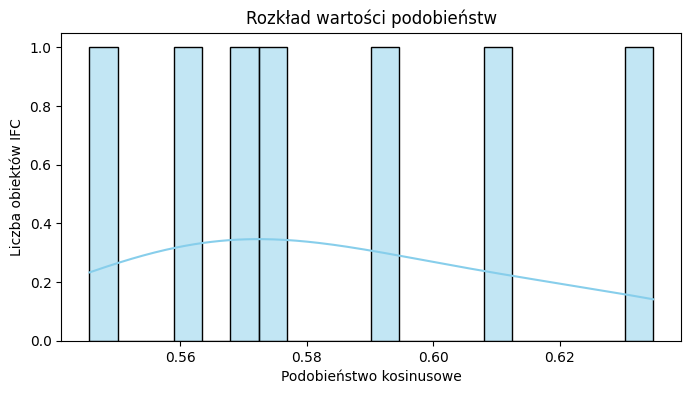

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Podstawowe statystyki
print("Liczba obiektów IFC:", len(final_df))
print("Liczba unikalnych kodów:", final_df["Chosen_Code"].nunique())

# Histogram score wybranej etykiety
plt.figure(figsize=(8,4))
sns.histplot(final_df["Chosen_Score"], bins=20, kde=True, color="skyblue")
plt.title("Rozkład wartości podobieństw")
plt.xlabel("Podobieństwo kosinusowe")
plt.ylabel("Liczba obiektów IFC")
plt.show()


KLASTER 1 (7 elementów)


,GlobalId,IfcType,Name,Opis_IFC,Top1_Kod_bSDD
0,3zR0BOEcLADRKln4HYporH,IFCSLAB,floor,"A solid, site-cast concrete floor, providing a...",L-BF
1,1AQAupaRP1txwK1AGiN61V,IFCWALL,house - outer wall - house right front,"A solid outer wall, forming the right front si...",L-BD
2,3wdauVJT5Fx9drrREiDqA$,IFCWALL,house - outer wall - house right back,"A solid outer wall, forming the right back sid...",L-BD
3,0OfZwWc8j9QP5uX8xPTxDH,IFCWALL,house - outer wall - house left,"A solid outer wall, forming the left side of t...",L-BD
4,1uS5vfZPn9R8PlAaVd73on,IFCWALL,plumbing wall,A wall designed to house and protect plumbing ...,L-BD
5,0ZTBBPo6f6bxqV2K7Oelrq,IFCSLAB,house - roof - slab left,A roof slab that's got it all covered. IsExter...,L-BE
6,12UVOn4wvAJPMUExKdZLb8,IFCSLAB,house - roof - slab right,A roof slab that's got it all covered. IsExter...,L-BE



Dominujące klasyfikacje w klastrach


,Cluster,Top1_Kod_bSDD,Count
0,1,L-BD,4
1,1,L-BE,2
2,1,L-BF,1


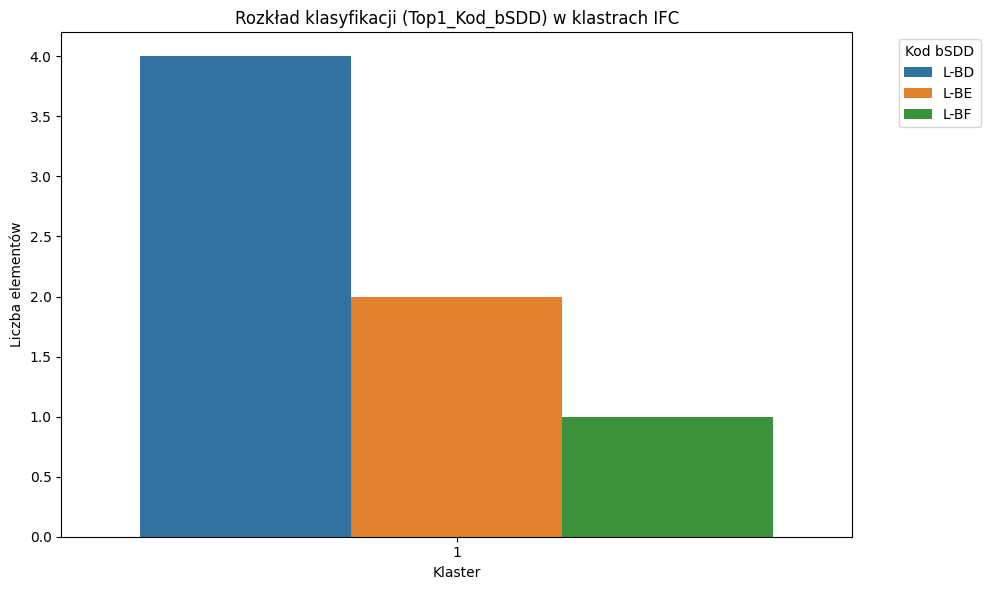

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Czytelne tabelaryczne podsumowanie
for cluster_id, group in df_ifc_clusters.groupby("Cluster"):
    print(f"\nKLASTER {cluster_id} ({len(group)} elementów)")
    display(
        group[["GlobalId", "IfcType", "Name", "Opis_IFC", "Top1_Kod_bSDD"]]
        .reset_index(drop=True)
    )

# 2. Podsumowanie dominujących kodów
cluster_dominance = (
    df_ifc_clusters.groupby(["Cluster", "Top1_Kod_bSDD"])
    .size()
    .reset_index(name="Count")
)

print("\nDominujące klasyfikacje w klastrach")
display(cluster_dominance)

# 3. Wizualizacja – słupki zliczające kody w klastrach
plt.figure(figsize=(10,6))
sns.barplot(
    data=cluster_dominance,
    x="Cluster", y="Count", hue="Top1_Kod_bSDD"
)
plt.title("Rozkład klasyfikacji (Top1_Kod_bSDD) w klastrach IFC")
plt.xlabel("Klaster")
plt.ylabel("Liczba elementów")
plt.legend(title="Kod bSDD", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()